
# Power Module Usage

In this example, we look at how to use the Power Module for a pre-test analysis. We will use the sales dataset from Meta.


In [5]:
import pandas as pd 

from panel_exp.design import power
from panel_exp.methods.tbr import TBRRidge
from panel_exp.panel_data import PanelDataset, TimePeriod

#import multiprocessing

# number of processors 
# Normally, we would use the following code to get the number of processors and use multiprocessing. But, auto-docuemntation does not support multiprocessing.
# n_proc = multiprocessing.cpu_count()


long_df = pd.read_csv('meta_geo.csv')

# trim data to only include pre-test data
long_df = long_df[long_df.time < 91]
wide_df = pd.pivot_table(long_df, index='location', columns='time', values='Y')
pds = PanelDataset(wide_df  )

print(pds)





ImportError: attempted relative import with no known parent package

In [2]:
# aggregate data for TBR
control_units = pd.DataFrame(wide_df.loc[[unit for unit in pds.units if unit not in ['chicago', 'cincinnati', 'houston', 'portland', 'honolulu']]] ).T
treated_units = pd.DataFrame(wide_df.loc[['chicago', 'cincinnati', 'houston', 'portland']].mean(axis=0), columns=['treated'])
wide_agg = pd.concat([treated_units, control_units], axis=1)

end = wide_df.columns[-1]
L = len(wide_df.columns)
test_length = 14

panel_data = PanelDataset(wide_agg.T, treated_units = ['treated'], treated_periods=[TimePeriod(start=L-test_length)])



pa = power.PowerAnalysis(panel_data
                         , TBRRidge
                         , 'Kfold'
                         , test_length
                         , mx_effect=.25 
                         , n_jobs=1) # here we would use n_jobs=n_proc

pa.run_analysis()

NameError: name 'wide_df' is not defined

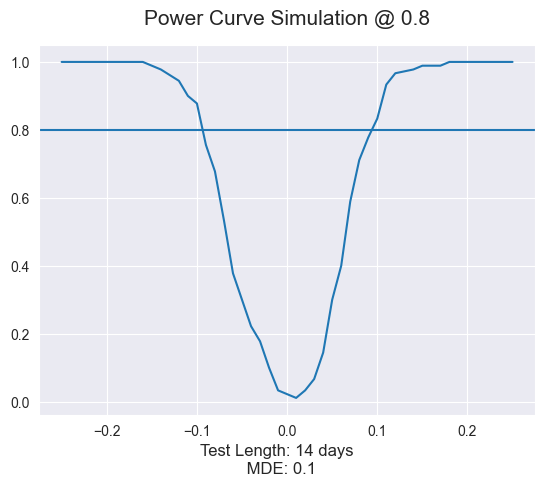

In [3]:
pa.plot_power_curve()



In [4]:
pa.summary()

,Parameters
Model,TBRRidge
Inference,Kfold
Test Length,14
Number of Simulations,4410
,Statistics
MDE Percent,-0.1
MDE KPI,-4873.134259
Power,0.8
Type 1 Error Rate,0.044444
